# Commercial Support for executorlib
The `executorlib` package is available via the anaconda `main-x`channel, so users of the commercial anaconda distribution can use it. 

## Installation
Get a copy of miniconda from: [anaconda.com/download](https://www.anaconda.com/download)

Afterwards, install it (on linux) using: `bash Miniconda3-latest-Linux-x86_64.sh`

For other operation systems the installation might differ slightly. 

Finally, login to your [anaconda.com](https://www.anaconda.com) account from the command line using: `anaconda login` 

This command is going to redirect you to the following website: [auth.anaconda.com/ui/activate](https://auth.anaconda.com/ui/activate) to activate your [anaconda.com](https://www.anaconda.com) account on your current device. 

### Conda Config
Add the corresponding channels to your conda configuration:
```
conda config --append default_channels https://repo.anaconda.com/pkgs/main
conda config --append default_channels https://repo.anaconda.cloud/repo/main-x
```

For more details how to setup the `main-x` channel, take a look at the [official documentation](https://www.anaconda.com/docs/getting-started/main-x).

### Install executorlib

Afterwards, you can install `executorlib` using:

```
conda install executorlib
```

For a more extensive typical environment you could install `executorlib` with a number of additional dependencies: 
```
conda install executorlib pysqa jupyter h5py pygraphviz networkx
```

### Validate environment
When you call `conda list` the `executorlib` package is listed as:
```
executorlib                 1.10.2           pypi_0
```

Your version number might differ depending on when you installed `executorlib`.

## Example

In [1]:
import executorlib as el

### Basic Usage

In [2]:
with el.SingleNodeExecutor() as exe:
    future = exe.submit(sum, [1, 1])
    print(future.result())

2


### MPI parallel Python Function

In [3]:
def calc_mpi(i):
    from mpi4py import MPI

    size = MPI.COMM_WORLD.Get_size()
    rank = MPI.COMM_WORLD.Get_rank()
    return i, size, rank

In [4]:
with el.SingleNodeExecutor() as exe:
    fs = exe.submit(calc_mpi, 3, resource_dict={"cores": 2})
    print(fs.result())

[(3, 2, 0), (3, 2, 1)]


### Caching 

In [5]:
with el.SingleNodeExecutor(cache_directory="./cache") as exe:
    future_lst = [exe.submit(sum, [i, i]) for i in range(1, 4)]
    print([f.result() for f in future_lst])

[2, 4, 6]


### Graph Visualization

In [6]:
def calc_add(a, b):
    return a + b

None


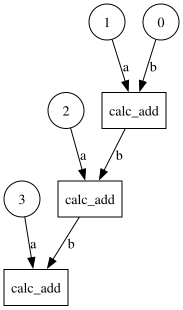

In [7]:
with el.SingleNodeExecutor(plot_dependency_graph=True) as exe:
    future = 0
    for i in range(1, 4):
        future = exe.submit(calc_add, i, future)
    print(future.result())

### HPC job schedulers
The `pysqa` package is available in addition to the `executorlib` package, so the advanced `executorlib` executors like `SlurmClusterExecutor`, `SlurmJobExecutor`, `FluxClusterExecutor` and `FluxJobExecutor` are available as well. Still they require a job scheduler to be installed, so they cannot be demonstrated in this notebook. 